<a href="https://colab.research.google.com/github/anushah-200/factcheckAI/blob/main/notebooks/14_day3_feature_ablation_error_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

DATA_PATH = "/content/drive/MyDrive/factcheckAI/outputs/factcheck_clean_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["Hallucination"].value_counts())

print("\nModel distribution:")
print(df["Model"].value_counts())


Shape: (806, 19)

Columns:
['Question', 'Ground_Truth', 'Category', 'Type', 'Model', 'Response', 'SemanticSimilarity', 'BLEU', 'ROUGE1', 'ROUGEL', 'BERTScore', 'ResponseLength', 'GroundTruthLength', 'QuestionLength', 'LengthDifference', 'ResponseCharacters', 'AverageWordLength', 'Hallucination', 'Question_ID']

Missing values:
Question              0
Ground_Truth          0
Category              0
Type                  0
Model                 0
Response              0
SemanticSimilarity    0
BLEU                  0
ROUGE1                0
ROUGEL                0
BERTScore             0
ResponseLength        0
GroundTruthLength     0
QuestionLength        0
LengthDifference      0
ResponseCharacters    0
AverageWordLength     0
Hallucination         0
Question_ID           0
dtype: int64

Target distribution:
Hallucination
1    440
0    366
Name: count, dtype: int64

Model distribution:
Model
OpenAI      279
DeepSeek    270
Groq        257
Name: count, dtype: int64


In [ ]:
question_to_qid = df.groupby("Question")["Question_ID"].nunique()

qid_to_question = df.groupby("Question_ID")["Question"].nunique()

print(
    "Questions mapped to multiple Question_IDs:",
    (question_to_qid > 1).sum()
)

print(
    "Question_IDs mapped to multiple Questions:",
    (qid_to_question > 1).sum()
)


Questions mapped to multiple Question_IDs: 0
Question_IDs mapped to multiple Questions: 0


In [ ]:
question_groups = df["Question_ID"].unique()

print("Total unique Question_IDs:", len(question_groups))


Total unique Question_IDs: 389


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [ ]:
train_qids, test_qids = train_test_split(
    question_groups,
    test_size=0.20,
    random_state=42
)

print("Training Question_IDs:", len(train_qids))
print("Testing Question_IDs:", len(test_qids))


Training Question_IDs: 311
Testing Question_IDs: 78


In [ ]:
train_df = df[df["Question_ID"].isin(train_qids)].copy()
test_df = df[df["Question_ID"].isin(test_qids)].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Train shape: (642, 19)
Test shape: (164, 19)


In [ ]:
train_question_ids = set(train_df["Question_ID"])
test_question_ids = set(test_df["Question_ID"])

overlap = train_question_ids.intersection(test_question_ids)

print("Question_ID overlap:", len(overlap))

if len(overlap) == 0:
    print("PASS: No Question_ID leakage.")
else:
    print("FAIL: Question_ID leakage detected!")


Question_ID overlap: 0
PASS: No Question_ID leakage.


In [ ]:
print("TRAIN CLASS DISTRIBUTION")
print(train_df["Hallucination"].value_counts())
print(train_df["Hallucination"].value_counts(normalize=True))

print("\nTEST CLASS DISTRIBUTION")
print(test_df["Hallucination"].value_counts())
print(test_df["Hallucination"].value_counts(normalize=True))


TRAIN CLASS DISTRIBUTION
Hallucination
1    354
0    288
Name: count, dtype: int64
Hallucination
1    0.551402
0    0.448598
Name: proportion, dtype: float64

TEST CLASS DISTRIBUTION
Hallucination
1    86
0    78
Name: count, dtype: int64
Hallucination
1    0.52439
0    0.47561
Name: proportion, dtype: float64


In [ ]:
FULL_FEATURES = [
    "Category",
    "Type",
    "ResponseLength",
    "QuestionLength",
    "ResponseCharacters",
    "AverageWordLength"
]

RESPONSE_FEATURES = [
    "ResponseLength",
    "ResponseCharacters",
    "AverageWordLength"
]

QUESTION_FEATURES = [
    "Category",
    "Type",
    "QuestionLength"
]

TARGET = "Hallucination"


In [ ]:
print("Full features:")
print(FULL_FEATURES)

print("\nResponse-only features:")
print(RESPONSE_FEATURES)

print("\nQuestion-only features:")
print(QUESTION_FEATURES)


Full features:
['Category', 'Type', 'ResponseLength', 'QuestionLength', 'ResponseCharacters', 'AverageWordLength']

Response-only features:
['ResponseLength', 'ResponseCharacters', 'AverageWordLength']

Question-only features:
['Category', 'Type', 'QuestionLength']


In [ ]:
FORBIDDEN_FEATURES = [
    "Model",
    "Question",
    "Response",
    "Question_ID",
    "Semantic Similarity",
    "BERTScore",
    "BLEU",
    "ROUGE-1",
    "ROUGE-L"
]

for feature_set_name, feature_set in {
    "Full": FULL_FEATURES,
    "Response-only": RESPONSE_FEATURES,
    "Question-only": QUESTION_FEATURES
}.items():

    leakage = [
        feature for feature in feature_set
        if feature in FORBIDDEN_FEATURES
    ]

    print(feature_set_name, "forbidden features:", leakage)


Full forbidden features: []
Response-only forbidden features: []
Question-only forbidden features: []


In [ ]:
def get_feature_types(features):
    categorical_features = [
        feature
        for feature in features
        if df[feature].dtype == "object"
    ]

    numerical_features = [
        feature
        for feature in features
        if feature not in categorical_features
    ]

    return categorical_features, numerical_features


In [ ]:
def run_random_forest(
    train_data,
    test_data,
    features,
    feature_set_name
):

    categorical_features, numerical_features = get_feature_types(features)

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                categorical_features
            ),
            (
                "numerical",
                "passthrough",
                numerical_features
            )
        ]
    )

    X_train = train_data[features]
    X_test = test_data[features]

    y_train = train_data[TARGET]
    y_test = test_data[TARGET]

    # Fit preprocessing only on training data
    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    # Random Forest
    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_processed, y_train)

    # Predictions
    y_pred = rf.predict(X_test_processed)
    y_prob = rf.predict_proba(X_test_processed)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    cm = confusion_matrix(y_test, y_pred)

    results = {
        "Split": "Question-Grouped",
        "Feature_Set": feature_set_name,
        "Model": "Random Forest",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    }

    return results, rf, preprocessor, cm, y_test, y_pred, y_prob


In [ ]:
full_result, full_rf, full_preprocessor, full_cm, full_y_test, full_y_pred, full_y_prob = run_random_forest(
    train_df,
    test_df,
    FULL_FEATURES,
    "Full"
)

print(full_result)


{'Split': 'Question-Grouped', 'Feature_Set': 'Full', 'Model': 'Random Forest', 'Accuracy': 0.75, 'Precision': 0.7419354838709677, 'Recall': 0.8023255813953488, 'F1': 0.770949720670391, 'ROC-AUC': np.float64(0.857334525939177)}


In [ ]:
response_result, response_rf, response_preprocessor, response_cm, response_y_test, response_y_pred, response_y_prob = run_random_forest(
    train_df,
    test_df,
    RESPONSE_FEATURES,
    "Response-only"
)

print(response_result)


{'Split': 'Question-Grouped', 'Feature_Set': 'Response-only', 'Model': 'Random Forest', 'Accuracy': 0.4817073170731707, 'Precision': 0.5051546391752577, 'Recall': 0.5697674418604651, 'F1': 0.5355191256830601, 'ROC-AUC': np.float64(0.5195289206917114)}


In [ ]:
question_result, question_rf, question_preprocessor, question_cm, question_y_test, question_y_pred, question_y_prob = run_random_forest(
    train_df,
    test_df,
    QUESTION_FEATURES,
    "Question-only"
)

print(question_result)


{'Split': 'Question-Grouped', 'Feature_Set': 'Question-only', 'Model': 'Random Forest', 'Accuracy': 0.7317073170731707, 'Precision': 0.75, 'Recall': 0.7325581395348837, 'F1': 0.7411764705882353, 'ROC-AUC': np.float64(0.8035181872391173)}


In [ ]:
ablation_results = pd.DataFrame([
    full_result,
    response_result,
    question_result
])

ablation_results


,Split,Feature_Set,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Question-Grouped,Full,Random Forest,0.750000,0.741935,0.802326,0.770950,0.857335
1,Question-Grouped,Response-only,Random Forest,0.481707,0.505155,0.569767,0.535519,0.519529
2,Question-Grouped,Question-only,Random Forest,0.731707,0.750000,0.732558,0.741176,0.803518


In [ ]:
OUTPUT_PATH = "/content/drive/MyDrive/factcheckAI/outputs/day3_feature_ablation_results.csv"

ablation_results.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Saved to:")
print(OUTPUT_PATH)


Saved to:
/content/drive/MyDrive/factcheckAI/outputs/day3_feature_ablation_results.csv


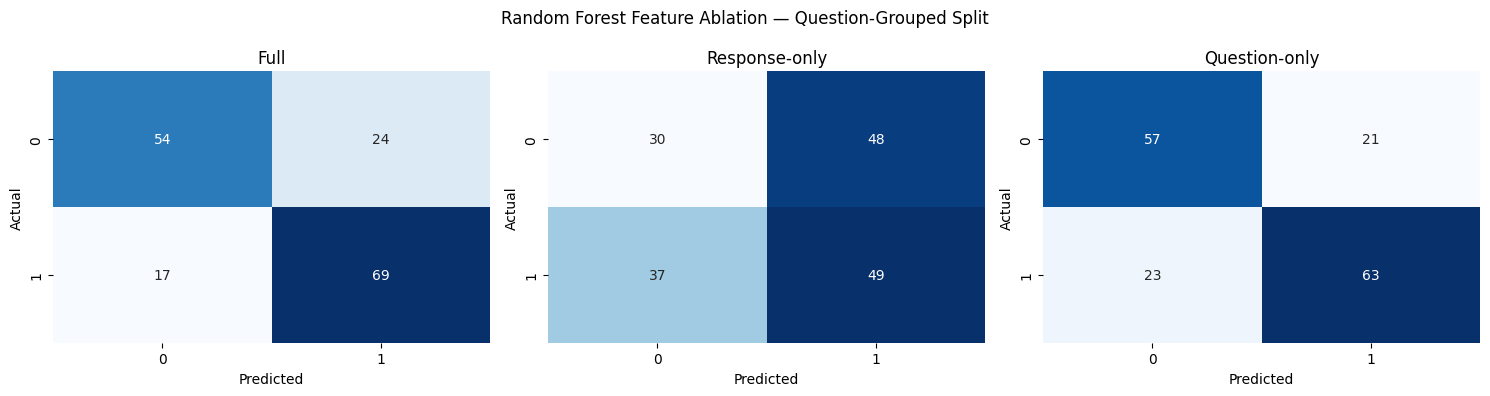

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

confusion_data = [
    ("Full", full_cm),
    ("Response-only", response_cm),
    ("Question-only", question_cm)
]

for ax, (name, cm) in zip(axes, confusion_data):

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle(
    "Random Forest Feature Ablation — Question-Grouped Split"
)

plt.tight_layout()
plt.show()


In [ ]:
FIG_PATH = "/content/drive/MyDrive/factcheckAI/outputs/day3_feature_ablation_confusion_matrices.png"

fig.savefig(
    FIG_PATH,
    dpi=300,
    bbox_inches="tight"
)

print("Saved:", FIG_PATH)


Saved: /content/drive/MyDrive/factcheckAI/outputs/day3_feature_ablation_confusion_matrices.png


In [ ]:
feature_names = full_preprocessor.get_feature_names_out()

importances = full_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    "Importance",
    ascending=False
)

feature_importance_df.head(20)


,Feature,Importance
41,numerical__QuestionLength,0.132812
42,numerical__ResponseCharacters,0.132052
40,numerical__ResponseLength,0.112161
43,numerical__AverageWordLength,0.100184
20,categorical__Category_Misconceptions,0.049969
14,categorical__Category_Indexical Error: Other,0.049184
10,categorical__Category_Health,0.037417
15,categorical__Category_Indexical Error: Time,0.036665
6,categorical__Category_Economics,0.033211
22,categorical__Category_Misinformation,0.028712


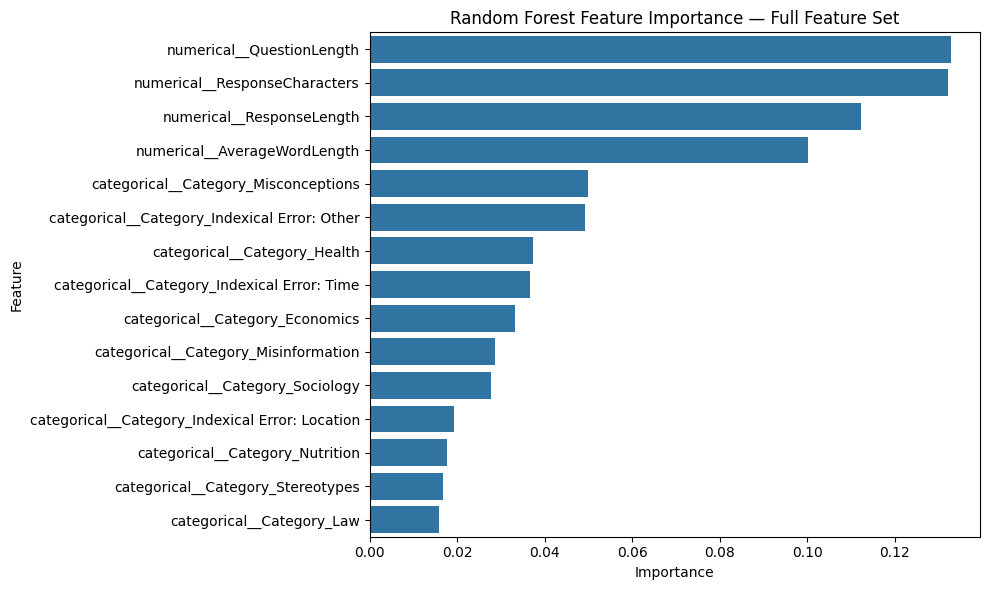

In [ ]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance — Full Feature Set")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


In [ ]:
FEATURE_IMPORTANCE_PATH = "/content/drive/MyDrive/factcheckAI/outputs/day3_feature_importance.png"

plt.savefig(
    FEATURE_IMPORTANCE_PATH,
    dpi=300,
    bbox_inches="tight"
)

print("Saved:", FEATURE_IMPORTANCE_PATH)


Saved: /content/drive/MyDrive/factcheckAI/outputs/day3_feature_importance.png


<Figure size 640x480 with 0 Axes>

In [ ]:

def generate_lomo_predictions(train_models, test_model):

    train_df = df[df["Model"].isin(train_models)].copy()
    test_df = df[df["Model"] == test_model].copy()

    # Same preprocessing as existing LOMO
    X_train, X_test, y_train, y_test = build_features(
        train_df,
        test_df
    )

    # Same RF settings as existing LOMO
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    y_proba = rf.predict_proba(X_test)[:, 1]

    predictions = test_df.copy()

    predictions["Prediction"] = y_pred
    predictions["Prediction_Probability"] = y_proba
    predictions["LOMO_Train_Models"] = "+".join(train_models)
    predictions["LOMO_Test_Model"] = test_model

    return predictions


In [ ]:
# ===== COMPLETE DAY 3 LOMO SETUP =====

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

BASE = "/content/drive/MyDrive/factcheckAI/outputs/"

# Load dataset
df = pd.read_csv(BASE + "factcheck_clean_dataset.csv")

# Features used by the ORIGINAL LOMO pipeline
CAT_FEATURES = ["Category", "Type"]

NUM_FEATURES = [
    "ResponseLength",
    "QuestionLength",
    "ResponseCharacters",
    "AverageWordLength"
]

TARGET = "Hallucination"

# LOMO experiments
LOMO_EXPERIMENTS = [
    (["OpenAI", "Groq"], "DeepSeek"),
    (["OpenAI", "DeepSeek"], "Groq"),
    (["Groq", "DeepSeek"], "OpenAI"),
]

print("Setup successful")
print("Dataset:", df.shape)
print("Models:", df["Model"].value_counts().to_dict())
print("LOMO experiments:", len(LOMO_EXPERIMENTS))


Setup successful
Dataset: (806, 19)
Models: {'OpenAI': 279, 'DeepSeek': 270, 'Groq': 257}
LOMO experiments: 3


In [ ]:
def build_features(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    # Encode categorical features using training data only
    for col in CAT_FEATURES:
        le = LabelEncoder()
        le.fit(train_df[col].astype(str))

        known = set(le.classes_)

        train_df[col + "_enc"] = le.transform(
            train_df[col].astype(str)
        )

        test_df[col + "_enc"] = test_df[col].astype(str).apply(
            lambda x: le.transform([x])[0] if x in known else -1
        )

    # Scale numerical features using training data only
    scaler = StandardScaler()

    train_num = scaler.fit_transform(
        train_df[NUM_FEATURES]
    )

    test_num = scaler.transform(
        test_df[NUM_FEATURES]
    )

    # Combine categorical + numerical features
    train_cat = train_df[
        [c + "_enc" for c in CAT_FEATURES]
    ].values

    test_cat = test_df[
        [c + "_enc" for c in CAT_FEATURES]
    ].values

    X_train = np.hstack([
        train_cat,
        train_num
    ])

    X_test = np.hstack([
        test_cat,
        test_num
    ])

    return (
        X_train,
        X_test,
        train_df[TARGET].values,
        test_df[TARGET].values
    )


In [ ]:
lomo_prediction_dfs = []

for train_models, test_model in LOMO_EXPERIMENTS:

    predictions = generate_lomo_predictions(
        train_models,
        test_model
    )

    lomo_prediction_dfs.append(predictions)

    print(
        f"Train {train_models} -> Test {test_model}: "
        f"{len(predictions)} predictions"
    )


Train ['OpenAI', 'Groq'] -> Test DeepSeek: 270 predictions
Train ['OpenAI', 'DeepSeek'] -> Test Groq: 257 predictions
Train ['Groq', 'DeepSeek'] -> Test OpenAI: 279 predictions


In [ ]:
lomo_predictions = pd.concat(
    lomo_prediction_dfs,
    ignore_index=True
)

output_path = BASE + "day3_lomo_predictions.csv"

lomo_predictions.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)
print("Total predictions:", len(lomo_predictions))
print("\nColumns:")
print(lomo_predictions.columns.tolist())


Saved: /content/drive/MyDrive/factcheckAI/outputs/day3_lomo_predictions.csv
Total predictions: 806

Columns:
['Question', 'Ground_Truth', 'Category', 'Type', 'Model', 'Response', 'SemanticSimilarity', 'BLEU', 'ROUGE1', 'ROUGEL', 'BERTScore', 'ResponseLength', 'GroundTruthLength', 'QuestionLength', 'LengthDifference', 'ResponseCharacters', 'AverageWordLength', 'Hallucination', 'Question_ID', 'Prediction', 'Prediction_Probability', 'LOMO_Train_Models', 'LOMO_Test_Model']
